# Cenário

A **LogiFast** é uma empresa de logística responsável pelo transporte de mercadorias, gestão de estoque e entrega de encomendas para diversas outras empresas. Apesar de ter experimentado um crescimento considerável nos últimos anos, a empresa vem enfrentando desafios significativos em relação à sua eficiência operacional.

**O Problema:**

Recentemente a diretoria da LogiFast percebeu que os custos operacionais estão aumentando, enquanto a eficiência na operação e a satisfação do cliente estão diminuindo. Isso vem ocorrendo principalmente pelo atraso constante nas entregas e pela alta na devolução de pedidos.

**A Base de Dados:**

Para entender melhor esses problemas e *buscar soluções baseadas em dados*, a empresa solicitou ao seu departamente de TI um relatório *(base_dados.xlsx)* com as seguintes informações:

- Número do pedido
- Nome do cliente
- Motorista responsável pela entrega
- Data de emissão do pedido
- Data prevista de entrega
- Estado Destino do pedido
- Quantidade de itens do pedido
- Valor total do pedido (em R$)
- Data de entrega
- Motivo da devolução
- Dias corridos até a entrega
- Status (se foi entregue no prazo ou não)

A LogiFast **contratou você como Analista de Dados** para responder algumas perguntas. Então, mãos à obra! 🚀

### 1 - Carregando os dados

Importe a biblioteca **Pandas** e carregue os dados do relatório **base_dados.xlsx** utilizando o método **read_excel()**.

In [1]:
import pandas as pd
import openpyxl

In [2]:
df_dados = pd.read_excel('dataset/base_dados.xlsx')

In [3]:
df_dados.head()

,numero_pedido,cliente,motorista,dt_emissao_pedido,dt_previsao_entrega,estado_destino,quantidade_itens,valor_pedido,dt_entrega,motivo_devolucao,dias_ate_entrega,status
0,A3,WALMART,FELIPE SILVA,2019-01-27,2019-02-06,SP,3,139.5,2019-02-03,S/ Devolu.,7,No Prazo
1,A4,MAGAZINE LUIZA,TÚLIO SILVEIRA,2019-01-28,2019-02-07,RJ,4,134.4,2019-02-12,S/ Devolu.,15,Atrasado
2,A7,MAGAZINE LUIZA,VALDIR ESPINOSA,2019-02-04,2019-02-14,SP,5,79.5,2019-02-14,Produto Errado,10,No Prazo
3,A12,MAGAZINE LUIZA,MARCOS LEROY,2019-02-18,2019-02-28,SP,20,326.0,2019-02-25,Produto Errado,7,No Prazo
4,A15,WALMART,LUIZ PARDAL,2019-02-21,2019-03-03,RJ,12,597.6,2019-03-07,S/ Devolu.,14,Atrasado


In [4]:
df_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4282 entries, 0 to 4281
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   numero_pedido        4282 non-null   object        
 1   cliente              4282 non-null   object        
 2   motorista            4282 non-null   object        
 3   dt_emissao_pedido    4282 non-null   datetime64[ns]
 4   dt_previsao_entrega  4282 non-null   datetime64[ns]
 5   estado_destino       4282 non-null   object        
 6   quantidade_itens     4282 non-null   int64         
 7   valor_pedido         4282 non-null   float64       
 8   dt_entrega           4282 non-null   datetime64[ns]
 9   motivo_devolucao     4282 non-null   object        
 10  dias_ate_entrega     4282 non-null   int64         
 11  status               4282 non-null   object        
dtypes: datetime64[ns](3), float64(1), int64(2), object(6)
memory usage: 401.6+ KB


### 2 - Verifique as 5 primeiras e as 5 últimas linhas

Agora vamos verificar se os dados foram carregados corretamente. Para isso, utilize os métodos **head()** e **tail()** para verificar as 5 primeiras e as 5 últimas linhas carregadas.

In [5]:
# Listando as 5 primeiras linhas do DataFrame
df_dados.head()

,numero_pedido,cliente,motorista,dt_emissao_pedido,dt_previsao_entrega,estado_destino,quantidade_itens,valor_pedido,dt_entrega,motivo_devolucao,dias_ate_entrega,status
0,A3,WALMART,FELIPE SILVA,2019-01-27,2019-02-06,SP,3,139.5,2019-02-03,S/ Devolu.,7,No Prazo
1,A4,MAGAZINE LUIZA,TÚLIO SILVEIRA,2019-01-28,2019-02-07,RJ,4,134.4,2019-02-12,S/ Devolu.,15,Atrasado
2,A7,MAGAZINE LUIZA,VALDIR ESPINOSA,2019-02-04,2019-02-14,SP,5,79.5,2019-02-14,Produto Errado,10,No Prazo
3,A12,MAGAZINE LUIZA,MARCOS LEROY,2019-02-18,2019-02-28,SP,20,326.0,2019-02-25,Produto Errado,7,No Prazo
4,A15,WALMART,LUIZ PARDAL,2019-02-21,2019-03-03,RJ,12,597.6,2019-03-07,S/ Devolu.,14,Atrasado


In [7]:
# Listando as 5 últimas linhas do DataFrame
df_dados.tail()

,numero_pedido,cliente,motorista,dt_emissao_pedido,dt_previsao_entrega,estado_destino,quantidade_itens,valor_pedido,dt_entrega,motivo_devolucao,dias_ate_entrega,status
4277,A9675,MAGAZINE LUIZA,VALDIR ESPINOSA,2021-11-27,2021-12-07,RJ,16,763.2,2021-12-15,Produto Errado,18,Atrasado
4278,A9676,WALMART,LUIZ PARDAL,2021-11-28,2021-12-08,SP,14,226.8,2021-12-12,Produto Errado,14,Atrasado
4279,A9680,CASA E VIDEO,TÚLIO SILVEIRA,2021-12-02,2021-12-12,SP,17,821.1,2021-12-20,Danificado,18,Atrasado
4280,A9681,RICARDO ELETRO,MARCOS LEROY,2021-12-03,2021-12-13,SP,1,49.8,2021-12-17,S/ Devolu.,14,Atrasado
4281,A9683,AMERICANAS,FELIPE SILVA,2021-12-06,2021-12-16,MG,15,715.5,2021-12-17,Produto Errado,11,Atrasado


### 3 - Verifique a quantidade de linhas e colunas carregadas

Utilize a propriedade **shape** para verificar a quantidade de linhas e colunas que foram carregadas.

In [8]:
print(df_dados.shape)
print(f"O DataFrame possue {df_dados.shape[0]} linhas e {df_dados.shape[1]} colunas.")

(4282, 12)
O DataFrame possue 4282 linhas e 12 colunas.


### 4 - Verifique o tipo de dado de cada coluna

Dessa vez, vamos usar o método **info()** para checar o tipo de dado de cada coluna. Isso é muito importante para identificarmos quais análises podem ser realizadas em cada uma delas.

In [9]:
df_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4282 entries, 0 to 4281
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   numero_pedido        4282 non-null   object        
 1   cliente              4282 non-null   object        
 2   motorista            4282 non-null   object        
 3   dt_emissao_pedido    4282 non-null   datetime64[ns]
 4   dt_previsao_entrega  4282 non-null   datetime64[ns]
 5   estado_destino       4282 non-null   object        
 6   quantidade_itens     4282 non-null   int64         
 7   valor_pedido         4282 non-null   float64       
 8   dt_entrega           4282 non-null   datetime64[ns]
 9   motivo_devolucao     4282 non-null   object        
 10  dias_ate_entrega     4282 non-null   int64         
 11  status               4282 non-null   object        
dtypes: datetime64[ns](3), float64(1), int64(2), object(6)
memory usage: 401.6+ KB


### 5 - Gerando estatísticas

Gere as estatísticas das seguintes colunas: quantidade_itens, valor_pedido, dias_ate_entrega. Para isso, utilize o método **describe()**.

In [10]:
df_dados[['quantidade_itens', 'valor_pedido', 'dias_ate_entrega']].describe().round(2)

,quantidade_itens,valor_pedido,dias_ate_entrega
count,4282.00,4282.00,4282.00
mean,10.49,339.04,13.12
std,5.80,244.82,3.82
min,1.00,15.00,3.00
25%,5.00,144.90,10.00
50%,11.00,279.00,13.00
75%,15.00,505.60,16.00
max,20.00,1020.00,20.00


### 6 - Liste a quantidade de pedidos por estado de destino

- Qual o estado com maior número de pedidos? -> MG com 1496 pedidos.
- Qual o estado com menor número de pedidos? -> RJ com 1374 pedidos.
- Crie um gráfico de barras com esses dados

In [13]:
df_dados['estado_destino'].value_counts()

estado_destino
MG    1496
SP    1412
RJ    1374
Name: count, dtype: int64

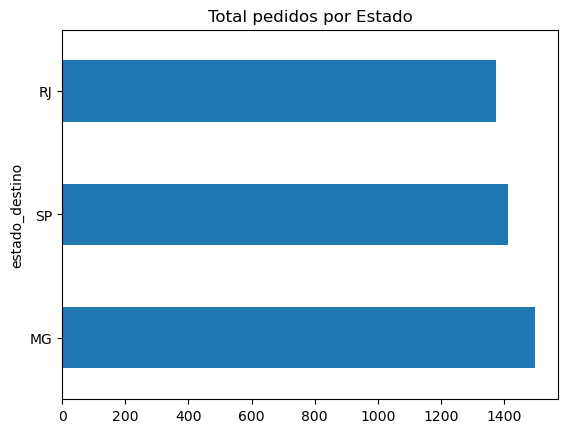

In [14]:
df_dados['estado_destino'].value_counts().plot(kind="barh", title="Total pedidos por Estado");

### 7 - Liste o total de pedidos por clientes

- Qual o cliente com a maior quantidade de pedidos? -> Walmart com 1157 pedidos.
- Qual o cliente com a menor quantidade de pedidos? -> Ricardo Eletro com 324 pedidos.
- Crie um gráfico de barras com esses dados


In [ ]:
df_dados['cliente'].value_counts()

cliente
WALMART           1157
CASAS BAHIA       1016
MAGAZINE LUIZA     809
AMERICANAS         591
CASA E VIDEO       385
RICARDO ELETRO     324
Name: count, dtype: int64

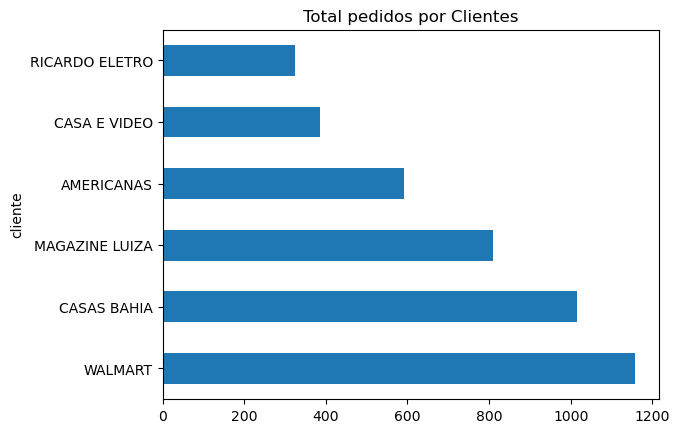

In [18]:
df_dados['cliente'].value_counts().plot(kind="barh", title="Total pedidos por Clientes");

### 8 - Liste a quantidade de pedidos por motorista

- Quem é o motorista com maior número de pedidos entregues? -> Marcos Leroy com 753 pedidos entregues.
- Quem é o motorista com menor número de pedidos entregues? -> Felipe Silva com 664 pedidos entregues.
- Crie um gráfico de barras com esses dados

In [19]:
df_dados['motorista'].value_counts()

motorista
MARCOS LEROY       753
LUIZ PARDAL        750
VALDIR ESPINOSA    732
TÚLIO SILVEIRA     698
JOÃO GOMES         685
FELIPE SILVA       664
Name: count, dtype: int64

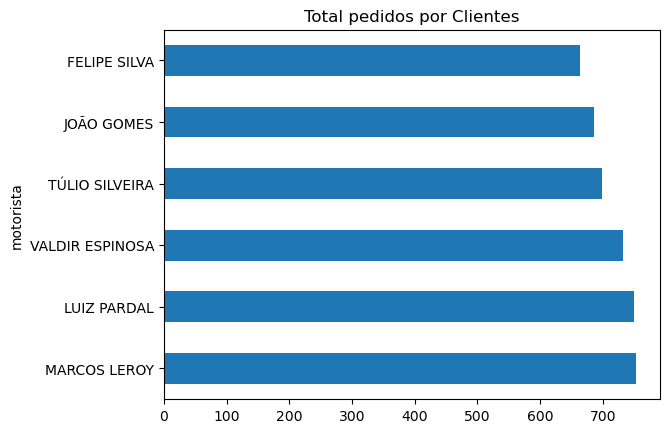

In [ ]:
df_dados['motorista'].value_counts().plot(kind="barh", title="Total pedidos entregues por Motorista");

### 9 - Contabilize os motivos de devolução por cliente

**ATENÇÃO:** considerar apenas os pedidos com devolução!

Para isso, vamos precisar realizar os seguintes passos:

- filtrar apenas os dados de pedidos com devolução.
- agrupar o resultado por cliente e motivo da devolução
- realizar a contagem pelo número do pedido

Qual o maior motivo de devolução de pedidos? -> Produto Errado.

In [24]:
df_dados.head()

,numero_pedido,cliente,motorista,dt_emissao_pedido,dt_previsao_entrega,estado_destino,quantidade_itens,valor_pedido,dt_entrega,motivo_devolucao,dias_ate_entrega,status
0,A3,WALMART,FELIPE SILVA,2019-01-27,2019-02-06,SP,3,139.5,2019-02-03,Sem Devolução,7,No Prazo
1,A4,MAGAZINE LUIZA,TÚLIO SILVEIRA,2019-01-28,2019-02-07,RJ,4,134.4,2019-02-12,Sem Devolução,15,Atrasado
2,A7,MAGAZINE LUIZA,VALDIR ESPINOSA,2019-02-04,2019-02-14,SP,5,79.5,2019-02-14,Produto Errado,10,No Prazo
3,A12,MAGAZINE LUIZA,MARCOS LEROY,2019-02-18,2019-02-28,SP,20,326.0,2019-02-25,Produto Errado,7,No Prazo
4,A15,WALMART,LUIZ PARDAL,2019-02-21,2019-03-03,RJ,12,597.6,2019-03-07,Sem Devolução,14,Atrasado


In [23]:
df_dados['motivo_devolucao'] = df_dados['motivo_devolucao'].replace('S/ Devolu.', 'Sem Devolução')

In [36]:
df_dados_devolucao = df_dados.loc[df_dados['motivo_devolucao'] != 'Sem Devolução']

In [37]:
df_dados_devolucao['motivo_devolucao'].value_counts()

motivo_devolucao
Produto Errado    2283
Danificado         618
Arrependimento     321
Name: count, dtype: int64

In [38]:
df_dados_devolucao.groupby(['cliente','motivo_devolucao'])['numero_pedido'].count().to_frame()

numero_pedido
cliente        motivo_devolucao               
AMERICANAS     Arrependimento               48
               Danificado                  129
               Produto Errado              281
CASA E VIDEO   Arrependimento               26
               Danificado                   54
               Produto Errado              202
CASAS BAHIA    Arrependimento               71
               Danificado                  133
               Produto Errado              539
MAGAZINE LUIZA Arrependimento               57
               Danificado                  103
               Produto Errado              456
RICARDO ELETRO Arrependimento               22
               Danificado                   27
               Produto Errado              209
WALMART        Arrependimento               97
               Danificado                  172
               Produto Errado              596

### 10 - Crie um relatório com o valor total do prejuízo causado por cada motivo de devolução, agrupado por cliente.

**ATENÇÃO:** considerar apenas os pedidos com devolução!

**Exporte esse relatório para um arquivo Excel!**

In [42]:
df_devolucao_valor = df_dados_devolucao.groupby(['cliente','motivo_devolucao'])['valor_pedido'].sum().to_frame()

In [45]:
# Quando usamos agrupamentos, as colunas agrupadas se tornam índices, então não usar index=false
df_devolucao_valor.to_excel('dataset/df_valor_devolucao.xlsx')

### 11 - Dos pedidos que não foram devolvidos, quantos foram entregues no prazo e quantos fora do prazo? Estenda essa análise por clientes e motoristas.
-> 765 pedidos foram entregues atrasados.
-> 295 pedidos foram entregues no prazo.

Para responder essa pergunta, vamos seguir os passos abaixo:

- filtrar apenas os pedidos sem devolução
- aplicar uma contagem no resultado, na coluna *status*
- agrupar os dados por cliente, motorista e status
- contabilizar a coluna número do pedido.

**Exporte o relatório final para um arquivo Excel!**

In [46]:
df_dados_sem_devolucao = df_dados.loc[df_dados['motivo_devolucao'] == 'Sem Devolução']

In [ ]:
df_dados_sem_devolucao['status'].value_counts()

status
Atrasado    765
No Prazo    295
Name: count, dtype: int64

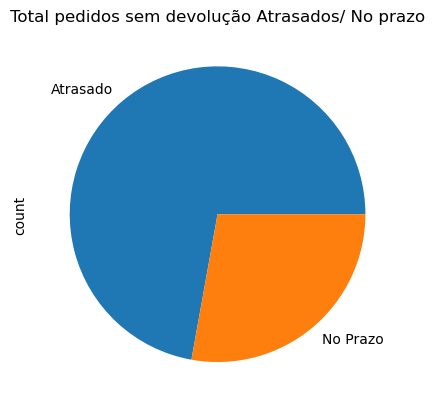

In [56]:
df_dados_sem_devolucao['status'].value_counts().plot(kind="pie", title="Total pedidos sem devolução Atrasados/ No prazo");

In [50]:
df_sem_devolucao = df_dados_sem_devolucao.groupby(['cliente','motorista','status'])['numero_pedido'].count().to_frame()

In [53]:
df_sem_devolucao

numero_pedido
cliente    motorista       status                 
AMERICANAS FELIPE SILVA    Atrasado             29
                           No Prazo             11
           JOÃO GOMES      Atrasado              1
           LUIZ PARDAL     Atrasado             28
                           No Prazo              5
...                                            ...
WALMART    MARCOS LEROY    No Prazo              1
           TÚLIO SILVEIRA  Atrasado             39
                           No Prazo             20
           VALDIR ESPINOSA Atrasado             65
                           No Prazo             19

[64 rows x 1 columns]

In [54]:
df_sem_devolucao.to_excel('dataset/df_sem_devolucao.xlsx')